# ML

## Libraries

In [62]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from pycaret.classification import *
import matplotlib.pyplot as plt  
import re
import string
import unicodedata
from hazm import stopwords_list    # pip install hazm

ModuleNotFoundError: No module named 'pycaret'

## Load and Get data 

In [134]:
data_train = pd.read_csv('train.csv', sep='\t')
data_test = pd.read_csv('test.csv', sep='\t')
data_dev = pd.read_csv('dev.csv', sep='\t')

In [35]:
dv_fine = pd.read_csv('df_1_final_clean.csv' , sep=',')
dt_fine = pd.read_csv('df_final_clean.csv',sep=',')
ds_fine = pd.read_csv('df_2_final_clean.csv',sep=',')

In [37]:
data_train

,Unnamed: 0,comment,label,label_id
0,0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1
1,1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,HAPPY,0
2,2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,SAD,1
3,3,عالللی بود همه چه درست و به اندازه و کیفیت خوب...,HAPPY,0
4,4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0
...,...,...,...,...
56695,56695,یک تیکه کم فرستاده بودن و با تماس من در کمترین...,HAPPY,0
56696,56696,عالی بود همه چیز ممنونم پیک هم خیلی مرتب و به ...,HAPPY,0
56697,56697,مثل همیشه عالی، من چندمین باره سفارش میدم و هر...,HAPPY,0
56698,56698,دلستر استوایی خواسته بودم اما لیمویی فرستادند,HAPPY,0


In [38]:
data_test

,Unnamed: 0,comment,label,label_id
0,0,خواهشا خواهشا خواهشا واسه ارسال شیرینیها یه فک...,HAPPY,0
1,1,غذا گرم رسید کیفیت و پخت گوشت عالی بود,HAPPY,0
2,2,قیمت سس شکلات روی بسته بندی ۱۵۰۰۰ بود ولی قیمت...,SAD,1
3,3,عکس توی پیج یه شیرینی شکری روشن رنگ هست که همم...,SAD,1
4,4,باز هم میگم، پیتزا نباید اینقد چرب باشه,SAD,1
...,...,...,...,...
6995,6995,سطح پیتزا سوخته بود متاسفانه و ارزش اون پولو ن...,SAD,1
6996,6996,بسته بندی خیلی بسیار بد شده,SAD,1
6997,6997,سلام خسته نباشید همه چی خوب بود فقط یک مقدار م...,HAPPY,0
6998,6998,غذا سرد و کیفیت قابل قبول نبود,SAD,1


In [39]:
data_dev

,Unnamed: 0,comment,label,label_id
0,0,همه ساندویچ‌ها سرد بود متاسفانه در صورتی که فا...,SAD,1
1,1,تشکر، عالی‌تر از همیشه,HAPPY,0
2,2,مرغ و کدو رو دوس نداشتم ولی کلا ساندویچهای خوش...,HAPPY,0
3,3,نمیدونم هزینه بسته بندی به چه دلیل گرفته شد؟؟؟,SAD,1
4,4,یک نوشابه کم ارسال شد و تاخیر فراوان و غذای نس...,SAD,1
...,...,...,...,...
6295,6295,سلام من به فاکتور غذاهایی که سفارش میدم احتیاج...,SAD,1
6296,6296,سایز پیتزا نسبت به سفارشاتی که قبلا گذشتم کم ش...,SAD,1
6297,6297,من قارچ اضافه رو اضافه کرده بودم بودم اما اگر ...,HAPPY,0
6298,6298,همرو بعد ۲ساعت تاخیر اشتباه آوردن پولشم رفت رو...,SAD,1


## Exploring data 

### Data_train

#### Data_train - General exploring

In [40]:
data_train.head(4)

,Unnamed: 0,comment,label,label_id
0,0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1
1,1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,HAPPY,0
2,2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,SAD,1
3,3,عالللی بود همه چه درست و به اندازه و کیفیت خوب...,HAPPY,0


In [42]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56700 entries, 0 to 56699
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  56700 non-null  int64 
 1   comment     56700 non-null  object
 2   label       56700 non-null  object
 3   label_id    56700 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 1.7+ MB


In [43]:
data_train.shape

(56700, 4)

#### data_train - Label exploring

In [46]:
data_train['label'].isna().sum()

np.int64(0)

In [48]:
data_train['label'].value_counts()

label
SAD      28350
HAPPY    28350
Name: count, dtype: int64

In [49]:
data_train['label'].unique()

array(['SAD', 'HAPPY'], dtype=object)

In [50]:
# no null - balanced - without any irelevent value 

#### data_train - label_id exploring 

In [51]:
data_train['label_id']

0        1
1        0
2        1
3        0
4        0
        ..
56695    0
56696    0
56697    0
56698    0
56699    1
Name: label_id, Length: 56700, dtype: int64

In [52]:
data_train['label_id'].isna().sum()

np.int64(0)

In [53]:
data_train['label_id'].value_counts()

label_id
1    28350
0    28350
Name: count, dtype: int64

In [55]:
data_train['label_id'].unique()

array([1, 0])

In [59]:
# no null - balanced - without any irelevent value 

#### checking label and label_id

In [60]:
data_train[['label','label_id']]

,label,label_id
0,SAD,1
1,HAPPY,0
2,SAD,1
3,HAPPY,0
4,HAPPY,0
...,...,...
56695,HAPPY,0
56696,HAPPY,0
56697,HAPPY,0
56698,HAPPY,0


In [61]:
inconsistent = data_train[~(
    ((data_train['label'] == 'SAD') & (data_train['label_id'] == 1)) |
    ((data_train['label'] == 'HAPPY') & (data_train['label_id'] == 0))
)]
print(f"number of invalid :  {len(inconsistent)}")
print(inconsistent)

number of invalid :  0
Empty DataFrame
Columns: [Unnamed: 0, comment, label, label_id]
Index: []


In [62]:
# so ===========> SAD is 1          &&          HAPPY is 0 

#### data_train - comment exploring 

In [63]:
data_train['comment']

0          واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
1        قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...
2        قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...
3        عالللی بود همه چه درست و به اندازه و کیفیت خوب...
4                            شیرینی وانیلی فقط یک مدل بود.
                               ...                        
56695    یک تیکه کم فرستاده بودن و با تماس من در کمترین...
56696    عالی بود همه چیز ممنونم پیک هم خیلی مرتب و به ...
56697    مثل همیشه عالی، من چندمین باره سفارش میدم و هر...
56698        دلستر استوایی خواسته بودم اما لیمویی فرستادند
56699    جای مرغ گریل شده ناگت بود، به این نمی‌گن چیکن ...
Name: comment, Length: 56700, dtype: object

In [64]:
data_train['comment'].isna().sum()

np.int64(0)

In [65]:
data_train['comment'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 56700 entries, 0 to 56699
Series name: comment
Non-Null Count  Dtype 
--------------  ----- 
56700 non-null  object
dtypes: object(1)
memory usage: 443.1+ KB


In [66]:
data_train['comment'].duplicated().sum()

np.int64(0)

In [69]:
# no null - no duaplicated 

### Data_dev

#### Data_dev - General exploring

In [142]:
data_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6300 non-null   int64 
 1   comment     6300 non-null   object
 2   label       6300 non-null   object
 3   label_id    6300 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 197.0+ KB


In [143]:
data_dev.head(4)

,Unnamed: 0,comment,label,label_id
0,0,همه ساندویچ‌ها سرد بود متاسفانه در صورتی که فا...,SAD,1
1,1,تشکر، عالی‌تر از همیشه,HAPPY,0
2,2,مرغ و کدو رو دوس نداشتم ولی کلا ساندویچهای خوش...,HAPPY,0
3,3,نمیدونم هزینه بسته بندی به چه دلیل گرفته شد؟؟؟,SAD,1


In [144]:
data_dev.shape

(6300, 4)

#### data_dev - label exploring

In [145]:
data_dev['label'].isna().sum()

np.int64(0)

In [146]:
data_dev['label'].value_counts()

label
SAD      3150
HAPPY    3150
Name: count, dtype: int64

In [147]:
data_dev['label'].unique()

array(['SAD', 'HAPPY'], dtype=object)

In [148]:
# no null - balanced - without any irelevent value 

#### data_dev - label_id exploring

In [149]:
data_dev['label_id'].isna().sum()

np.int64(0)

In [150]:
data_dev['label_id'].value_counts()

label_id
1    3150
0    3150
Name: count, dtype: int64

In [151]:
data_dev['label_id'].unique()

array([1, 0])

In [152]:
# no null - balanced - without any irelevent value 

#### checking label and label_id

In [154]:
data_train[['label','label_id']]

,label,label_id
0,SAD,1
1,HAPPY,0
2,SAD,1
3,HAPPY,0
4,HAPPY,0
...,...,...
56695,HAPPY,0
56696,HAPPY,0
56697,HAPPY,0
56698,HAPPY,0


In [153]:
inconsistent = data_dev[~(
    ((data_dev['label'] == 'SAD') & (data_dev['label_id'] == 1)) |
    ((data_dev['label'] == 'HAPPY') & (data_dev['label_id'] == 0))
)]
print(f"number of invalid :  {len(inconsistent)}")
print(inconsistent)

number of invalid :  0
Empty DataFrame
Columns: [Unnamed: 0, comment, label, label_id]
Index: []


In [155]:
# so ===========> SAD is 1          &&          HAPPY is 0 

#### data_dev - comment exploring 

In [156]:
data_dev['comment']

0       همه ساندویچ‌ها سرد بود متاسفانه در صورتی که فا...
1                                  تشکر، عالی‌تر از همیشه
2       مرغ و کدو رو دوس نداشتم ولی کلا ساندویچهای خوش...
3          نمیدونم هزینه بسته بندی به چه دلیل گرفته شد؟؟؟
4       یک نوشابه کم ارسال شد و تاخیر فراوان و غذای نس...
                              ...                        
6295    سلام من به فاکتور غذاهایی که سفارش میدم احتیاج...
6296    سایز پیتزا نسبت به سفارشاتی که قبلا گذشتم کم ش...
6297    من قارچ اضافه رو اضافه کرده بودم بودم اما اگر ...
6298    همرو بعد ۲ساعت تاخیر اشتباه آوردن پولشم رفت رو...
6299                               فلفلش خییییلی تند بود.
Name: comment, Length: 6300, dtype: object

In [157]:
data_dev['comment'].isna().sum()

np.int64(0)

In [158]:
data_dev['comment'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6300 entries, 0 to 6299
Series name: comment
Non-Null Count  Dtype 
--------------  ----- 
6300 non-null   object
dtypes: object(1)
memory usage: 49.3+ KB


In [160]:
data_dev['comment'].duplicated().sum()

np.int64(0)

In [161]:
# no null and duplicated

### Data_test 

#### data_test - General exploring

In [162]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  7000 non-null   int64 
 1   comment     7000 non-null   object
 2   label       7000 non-null   object
 3   label_id    7000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 218.9+ KB


In [163]:
data_test.shape

(7000, 4)

In [164]:
data_test.head(4)

,Unnamed: 0,comment,label,label_id
0,0,خواهشا خواهشا خواهشا واسه ارسال شیرینیها یه فک...,HAPPY,0
1,1,غذا گرم رسید کیفیت و پخت گوشت عالی بود,HAPPY,0
2,2,قیمت سس شکلات روی بسته بندی ۱۵۰۰۰ بود ولی قیمت...,SAD,1
3,3,عکس توی پیج یه شیرینی شکری روشن رنگ هست که همم...,SAD,1


#### data_test - label exploring 

In [165]:
data_test['label'].isna().sum()

np.int64(0)

In [166]:
data_test['label'].value_counts()

label
HAPPY    3500
SAD      3500
Name: count, dtype: int64

In [167]:
data_test['label'].unique()

array(['HAPPY', 'SAD'], dtype=object)

In [168]:
# no null - balanced - without any irelevent value 


#### data_test - label_id exploring 

In [169]:
data_test['label_id'].isna().sum()

np.int64(0)

In [170]:
data_test['label_id'].value_counts()

label_id
0    3500
1    3500
Name: count, dtype: int64

In [171]:
data_test['label_id'].unique()

array([0, 1])

In [172]:
# no null and irelevent values 

#### checking label and label_id

In [173]:
data_test[['label','label_id']]

,label,label_id
0,HAPPY,0
1,HAPPY,0
2,SAD,1
3,SAD,1
4,SAD,1
...,...,...
6995,SAD,1
6996,SAD,1
6997,HAPPY,0
6998,SAD,1


In [174]:
inconsistent = data_test[~(
    ((data_test['label'] == 'SAD') & (data_test['label_id'] == 1)) |
    ((data_test['label'] == 'HAPPY') & (data_test['label_id'] == 0))
)]
print(f"number of invalid :  {len(inconsistent)}")
print(inconsistent)

number of invalid :  0
Empty DataFrame
Columns: [Unnamed: 0, comment, label, label_id]
Index: []


In [175]:
# so ===========> SAD is 1          &&          HAPPY is 0 

#### data_test - comment exploring

In [176]:
data_test['comment']

0       خواهشا خواهشا خواهشا واسه ارسال شیرینیها یه فک...
1                  غذا گرم رسید کیفیت و پخت گوشت عالی بود
2       قیمت سس شکلات روی بسته بندی ۱۵۰۰۰ بود ولی قیمت...
3       عکس توی پیج یه شیرینی شکری روشن رنگ هست که همم...
4                 باز هم میگم، پیتزا نباید اینقد چرب باشه
                              ...                        
6995    سطح پیتزا سوخته بود متاسفانه و ارزش اون پولو ن...
6996                          بسته بندی خیلی بسیار بد شده
6997    سلام خسته نباشید همه چی خوب بود فقط یک مقدار م...
6998                       غذا سرد و کیفیت قابل قبول نبود
6999                یه کم خشک بود ولی در مجموع خوشمزه بود
Name: comment, Length: 7000, dtype: object

In [177]:
data_test['comment'].duplicated().sum()

np.int64(0)

In [178]:
data_test['comment'].isna().sum()

np.int64(0)

In [179]:
data_test['comment'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7000 entries, 0 to 6999
Series name: comment
Non-Null Count  Dtype 
--------------  ----- 
7000 non-null   object
dtypes: object(1)
memory usage: 54.8+ KB


In [ ]:
# no null and duplicated 

## Data cleaning & Preprocessing & Manipulating

### Data cleaning data_train

#### preprocess comment 

In [110]:
def normalize_persian(text):
    """Normalize Persian characters"""
    if not isinstance(text, str):
        return ""
    
    arabic_to_persian = {
        'ي': 'ی', 'ك': 'ک', 'دِ': 'ده', 'بِ': 'به', 'زِ': 'زه',
        'ذِ': 'ذه', 'شِ': 'شه', 'سِ': 'سه', 'ى': 'ی', 'ة': 'ه',
        'ﻷ': 'لا', 'ﻹ': 'لا', 'ﻵ': 'لا'
    }
    for ar, pe in arabic_to_persian.items():
        text = text.replace(ar, pe)
    
    return text

def remove_emojis(text):
    """Remove all emojis from text"""
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def remove_punctuations(text):
    """Remove all punctuation marks (Persian and English)"""
    persian_punctuations = '،؛؟!؟»«%٪×÷'
    english_punctuations = string.punctuation
    all_punctuations = persian_punctuations + english_punctuations
    
    translator = str.maketrans('', '', all_punctuations)
    return text.translate(translator)

def remove_numbers(text):
    """Remove all numbers (English and Persian)"""
    persian_numbers = '۰۱۲۳۴۵۶۷۸۹'
    english_numbers = '0123456789'
    all_numbers = persian_numbers + english_numbers
    
    translator = str.maketrans('', '', all_numbers)
    return text.translate(translator)

def remove_extra_spaces(text):
    """Remove extra spaces and strip"""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_single_characters(text):
    """Remove single character words"""
    return ' '.join([word for word in text.split() if len(word) > 1])

def remove_stopwords(text):
    """Remove Persian stopwords"""
    stopwords = set(stopwords_list())
    return ' '.join([word for word in text.split() if word not in stopwords])

def remove_english_letters(text):
    """Remove all English letters"""
    return re.sub(r'[a-zA-Z]', '', text)

def normalize_unicode(text):
    """Normalize unicode characters"""
    return unicodedata.normalize('NFKC', text)

def is_finglish(text):
    """Check if text is Finglish (Persian written with English letters)"""
    if not isinstance(text, str):
        return False
    
    text = text.strip()
    if len(text) == 0:
        return False
    
    persian_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    
    # If no Persian characters but has English letters
    if persian_chars == 0 and english_chars > 0:
        # Common Finglish patterns
        finglish_keywords = ['salam', 'chetori', 'khubi', 'mersi', 'lotf', 
                            'mamnun', 'khob', 'bale', 'na', 'are', 'man', 'to']
        text_lower = text.lower()
        for word in finglish_keywords:
            if word in text_lower:
                return True
        
        # Check for Finglish structure (vowels + common consonants)
        has_vowels = len(re.findall(r'[aeiouAEIOU]', text)) > 0
        has_common = len(re.findall(r'[sckhmnlrtypbgvz]', text.lower())) > 0
        
        return has_vowels and has_common
    
    return False

def is_english(text):
    """Check if text is pure English"""
    if not isinstance(text, str):
        return False
    
    text = text.strip()
    if len(text) == 0:
        return False
    
    persian_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    
    return persian_chars == 0 and english_chars > 0

def convert_finglish_to_persian(text):
    """Convert Finglish to Persian (simple mapping)"""
    if not isinstance(text, str):
        return ""
    
    # SimpleFinglish to Persian mapping
    finglish_map = {
        's': 'س', 'S': 'س',
        'a': 'ا', 'A': 'آ',
        'l': 'ل', 'L': 'ل',
        'm': 'م', 'M': 'م',
        'n': 'ن', 'N': 'ن',
        'k': 'ک', 'K': 'ک',
        'h': 'ه', 'H': 'ه',
        'i': 'ی', 'I': 'ی',
        'c': 'چ', 'C': 'چ',
        'b': 'ب', 'B': 'ب',
        'd': 'د', 'D': 'د',
        'e': 'ه', 'E': 'ه',
        'o': 'و', 'O': 'و',
        't': 'ت', 'T': 'ت',
        'r': 'ر', 'R': 'ر',
        'y': 'ی', 'Y': 'ی',
        'p': 'پ', 'P': 'پ',
        'g': 'گ', 'G': 'گ',
        'z': 'ز', 'Z': 'ز',
        'f': 'ف', 'F': 'ف',
        'v': 'و', 'V': 'و',
        'u': 'و', 'U': 'و',
        'x': 'خ', 'X': 'خ',
        'j': 'ج', 'J': 'ج',
        'w': 'و', 'W': 'و',
        'q': 'ق', 'Q': 'ق',
    }
    
    # Replace characters
    for eng, per in finglish_map.items():
        text = text.replace(eng, per)
    
    return text

def translate_english_to_persian(text):
    """Simple mapping for common English words to Persian"""
    if not isinstance(text, str):
        return ""
    
    english_to_persian = {
        'hello': 'سلام', 'hi': 'سلام', 'good': 'خوب', 'bad': 'بد',
        'yes': 'بله', 'no': 'نه', 'thank': 'متشکرم', 'thanks': 'متشکرم',
        'love': 'عشق', 'happy': 'خوشحال', 'sad': 'ناراحت', 'goodbye': 'خداحافظ',
        'ok': 'باشه', 'okay': 'باشه', 'nice': 'خوب', 'great': 'عالی',
        'perfect': 'عالی', 'awesome': 'عالی', 'amazing': 'عالی',
        'wow': 'وای', 'oh': 'آه', 'yeah': 'آره', 'yep': 'آره',
        'nope': 'نه', 'sorry': 'متاسفم', 'please': 'لطفا',
    }
    
    text_lower = text.lower()
    
    # Check if the whole text is a single English word
    if len(text.split()) == 1:
        if text_lower in english_to_persian:
            return english_to_persian[text_lower]
    
    # Try to translate word by word
    words = text.split()
    translated = []
    for word in words:
        word_lower = word.lower()
        if word_lower in english_to_persian:
            translated.append(english_to_persian[word_lower])
        elif word_lower.strip():
            translated.append(word)
    
    return ' '.join(translated)

def clean_persian_text_complete(text):
    """
    Complete text preprocessing for Persian text with Finglish and English support
    """
    if not isinstance(text, str):
        return ""
    
    # Step 1: Check if it's pure English
    if is_english(text):
        text = translate_english_to_persian(text)
    
    # Step 2: Check if it's Finglish
    if is_finglish(text):
        text = convert_finglish_to_persian(text)
    
    # Step 3: Normalize unicode
    text = normalize_unicode(text)
    
    # Step 4: Normalize Persian characters
    text = normalize_persian(text)
    
    # Step 5: Remove emojis
    text = remove_emojis(text)
    
    # Step 6: Remove punctuations
    text = remove_punctuations(text)
    
    # Step 7: Remove numbers
    text = remove_numbers(text)
    
    # Step 8: Remove English letters (if any left)
    text = remove_english_letters(text)
    
    # Step 9: Remove extra spaces
    text = remove_extra_spaces(text)
    
    # Step 10: Remove single characters
    text = remove_single_characters(text)
    
    # Step 11: Remove stopwords
    text = remove_stopwords(text)
    
    return text

def preprocess_dataframe(df, text_column='comment', label_column='label_id'):
    """
    Preprocess dataframe with complete cleaning
    
    Args:
        df: Input dataframe
        text_column: Name of text column
        label_column: Name of label column
    
    Returns:
        Cleaned dataframe with 'comment' and 'label_id' columns
    """
    # Create copy
    data = df.copy()
    
    # Apply complete cleaning
    data['comment_cleaned'] = data[text_column].apply(clean_persian_text_complete)
    
    # Select only needed columns
    if label_column in data.columns:
        data = data[['comment_cleaned', label_column]]
        data = data.rename(columns={label_column: 'label_id'})
    else:
        data = data[['comment_cleaned']]
        data['label_id'] = None# Rename cleaned column to comment
    data = data.rename(columns={'comment_cleaned': 'comment'})
    
    # Remove empty comments
    data = data[data['comment'].str.len() >= 2]
    
    return data

df = preprocess_dataframe(data_train, text_column='comment', label_column='label_id')

# Show results
print("=" * 50)
print("PREPROCESSING COMPLETE")
print("=" * 50)
print(f"Original shape: {data_train.shape}")
print(f"Final shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# Show sample comparison
print("\n" + "=" * 50)
print("SAMPLE COMPARISON")
print("=" * 50)

for i in range(min(5, len(data_train))):
    if len(data_train.iloc[i]['comment']) > 0:
        print(f"\nOriginal: {data_train.iloc[i]['comment']}")
        print(f"Cleaned: {df.iloc[i]['comment']}")
        print("-" * 50)

# Check for empty comments
empty_comments = df[df['comment'].str.len() < 2]
print(f"\nEmpty comments after preprocessing: {len(empty_comments)}")
print(f"Final dataset size: {len(df)}")

PREPROCESSING COMPLETE
Original shape: (56700, 4)
Final shape: (56556, 2)

Columns: ['comment', 'label_id']

SAMPLE COMPARISON

Original: واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
Cleaned: واقعا حیف وقت بنویسم سرویس دهیتون افتضاح
--------------------------------------------------

Original: قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون
Cleaned: قرار ساعته برسه نیم ساعت زودتر موقع ببین چقدرررررررررررر پلاک خفنههههه سالهاست مشتریشونم سالهاست مزه بهشت میده غذاشون
--------------------------------------------------

Original: قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ
Cleaned: قیمت مدل اصلا کیفیتش سازگاری نداره ظاهر فریبنده داره پرش میکنن کالباس قارچ
--------------------------------------------------

Original: عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم
Cleaned: عالللی درست اندازه 

In [111]:
df

,comment,label_id
0,واقعا حیف وقت بنویسم سرویس دهیتون افتضاح,1
1,قرار ساعته برسه نیم ساعت زودتر موقع ببین چقدرر...,0
2,قیمت مدل اصلا کیفیتش سازگاری نداره ظاهر فریبند...,1
3,عالللی درست اندازه کیفیت امیداورم کیفیتتون باش...,0
4,شیرینی وانیلی مدل,0
...,...,...
56695,تیکه فرستاده تماس کمترین زمان برام ارسال واقعا...,0
56696,ممنونم پیک مرتب موقع,0
56697,چندمین سفارش میدم هربارم دفعه راضی‌ترم سیب‌زمی...,0
56698,دلستر استوایی خواسته بودم لیمویی فرستادند,0


In [87]:
df['label_id'].value_counts()

label_id
1    28324
0    28232
Name: count, dtype: int64

In [88]:
""" make data_train to ====> df 
df has two column comment and label_id 
Label_Id is balanced 
COMMENT preprocessed  and cleaned and ready to extraction
1.remove number  
2.romove stopword  
3.remove punctuations 
4.remove emojis  
5.normolized  
6.translate 
7.convert finglish to persian 
8.remove space 
9.remove one charechter word"""

' make data_train to ====> df \ndf has two column comment and label_id \nLabel_Id is balanced \nCOMMENT preprocessed  and cleaned and ready to extraction\n1.remove number  \n2.romove stopword  \n3.remove punctuations \n4.remove emojis  \n5.normolized  \n6.translate \n7.convert finglish to persian \n8.remove space \n9.remove one charechter word'

#### Balancing

In [89]:
df['label_id'].value_counts()

label_id
1    28324
0    28232
Name: count, dtype: int64

In [92]:
# no need balancing 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56556 entries, 0 to 56699
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   comment   56556 non-null  object
 1   label_id  56556 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


#### shuffle 

In [112]:
df.reset_index(drop=True , inplace=True)

In [113]:
df

,comment,label_id
0,واقعا حیف وقت بنویسم سرویس دهیتون افتضاح,1
1,قرار ساعته برسه نیم ساعت زودتر موقع ببین چقدرر...,0
2,قیمت مدل اصلا کیفیتش سازگاری نداره ظاهر فریبند...,1
3,عالللی درست اندازه کیفیت امیداورم کیفیتتون باش...,0
4,شیرینی وانیلی مدل,0
...,...,...
56551,تیکه فرستاده تماس کمترین زمان برام ارسال واقعا...,0
56552,ممنونم پیک مرتب موقع,0
56553,چندمین سفارش میدم هربارم دفعه راضی‌ترم سیب‌زمی...,0
56554,دلستر استوایی خواسته بودم لیمویی فرستادند,0


In [116]:
df = shuffle(df)

In [117]:
df

,comment,label_id
39572,قیمت‌های روغن پاک روغنی گرمی ارسال نشد عوض گرم...,1
4967,اندازه پیتزا رستورانهای دیگه کوچیکتره طعمش کیف...,0
2411,طعم معمولی,0
46257,سلام عزیزم میکنم پیتزاهای تهران باشه پیتزا حتم...,0
1765,خدا قوت,0
...,...,...
45814,دمشون گرم,0
24559,مشتری حضوری اینجام مشتری اسنپ فود واقعا عالیه ...,0
38490,استفاده خامه کهنه سنگین دیگه سفارش نمیدم,1
1539,توی عکس سالادی برام اوردن فرق میوه نداشت مزه س...,1


In [118]:
df.reset_index(drop=True , inplace=True)

In [119]:
df

,comment,label_id
0,قیمت‌های روغن پاک روغنی گرمی ارسال نشد عوض گرم...,1
1,اندازه پیتزا رستورانهای دیگه کوچیکتره طعمش کیف...,0
2,طعم معمولی,0
3,سلام عزیزم میکنم پیتزاهای تهران باشه پیتزا حتم...,0
4,خدا قوت,0
...,...,...
56551,دمشون گرم,0
56552,مشتری حضوری اینجام مشتری اسنپ فود واقعا عالیه ...,0
56553,استفاده خامه کهنه سنگین دیگه سفارش نمیدم,1
56554,توی عکس سالادی برام اوردن فرق میوه نداشت مزه س...,1


#### Scaling 

In [120]:
# no need scaling 

#### Final checkout

In [121]:
df

,comment,label_id
0,قیمت‌های روغن پاک روغنی گرمی ارسال نشد عوض گرم...,1
1,اندازه پیتزا رستورانهای دیگه کوچیکتره طعمش کیف...,0
2,طعم معمولی,0
3,سلام عزیزم میکنم پیتزاهای تهران باشه پیتزا حتم...,0
4,خدا قوت,0
...,...,...
56551,دمشون گرم,0
56552,مشتری حضوری اینجام مشتری اسنپ فود واقعا عالیه ...,0
56553,استفاده خامه کهنه سنگین دیگه سفارش نمیدم,1
56554,توی عکس سالادی برام اوردن فرق میوه نداشت مزه س...,1


In [122]:
df['label_id'].isna().sum()

np.int64(0)

In [123]:
df['comment'].isna().sum()

np.int64(0)

In [124]:
df['label_id'].value_counts()

label_id
1    28324
0    28232
Name: count, dtype: int64

In [125]:
df['comment'].duplicated().sum()

np.int64(2245)

In [133]:
conflict_comments = (
    df.groupby('comment')['label_id']
      .nunique()
)

conflict_comments = conflict_comments[conflict_comments > 1].index


df_clean = df[~df['comment'].isin(conflict_comments)]


df_final = (
    df_clean
    .drop_duplicates(subset='comment', keep='first')
    .reset_index(drop=True)
)


print("=" * 60)
print("FINAL CLEANING COMPLETE")
print("=" * 60)

print(f"Original rows: {len(df)}")
print(f"Conflicting comments removed: {len(conflict_comments)}")
print(f"Rows after removing conflicts: {len(df_clean)}")
print(f"Duplicate comments removed: {len(df_clean) - len(df_final)}")
print(f"Final rows: {len(df_final)}")

print("\nLabel distribution:")
print(df_final['label_id'].value_counts())


df_final.to_csv("df_final_clean.csv", index=False)

FINAL CLEANING COMPLETE
Original rows: 56556
Conflicting comments removed: 193
Rows after removing conflicts: 55500
Duplicate comments removed: 1382
Final rows: 54118

Label distribution:
label_id
1    27715
0    26403
Name: count, dtype: int64


In [136]:
df_final

,comment,label_id
0,قیمت‌های روغن پاک روغنی گرمی ارسال نشد عوض گرم...,1
1,اندازه پیتزا رستورانهای دیگه کوچیکتره طعمش کیف...,0
2,طعم معمولی,0
3,سلام عزیزم میکنم پیتزاهای تهران باشه پیتزا حتم...,0
4,خدا قوت,0
...,...,...
54113,دمشون گرم,0
54114,مشتری حضوری اینجام مشتری اسنپ فود واقعا عالیه ...,0
54115,استفاده خامه کهنه سنگین دیگه سفارش نمیدم,1
54116,توی عکس سالادی برام اوردن فرق میوه نداشت مزه س...,1


In [137]:
df_final['comment'].duplicated().sum()

np.int64(0)

In [138]:
# حذف تکراری ها با لیبل های متفاوت و نگه داشتن یک از تکراری ها با داشتن لیبل یکسان 

In [139]:
df_final['label_id'].value_counts()

label_id
1    27715
0    26403
Name: count, dtype: int64

In [140]:
'''balanced , shuffled , reset indext , no null , no duplicated , scaled , cleaned text
READY FOR FEATURE EXTRACTION ''' 

'balanced , shuffled , reset indext , no null , no duplicated , scaled , cleaned text\nREADY FOR FEATURE EXTRACTION '

### Data cleaning data_dev

#### preprocess commemnt

In [6]:
def normalize_persian(text):
    """Normalize Persian characters"""
    if not isinstance(text, str):
        return ""
    
    arabic_to_persian = {
        'ي': 'ی', 'ك': 'ک', 'دِ': 'ده', 'بِ': 'به', 'زِ': 'زه',
        'ذِ': 'ذه', 'شِ': 'شه', 'سِ': 'سه', 'ى': 'ی', 'ة': 'ه',
        'ﻷ': 'لا', 'ﻹ': 'لا', 'ﻵ': 'لا'
    }
    for ar, pe in arabic_to_persian.items():
        text = text.replace(ar, pe)
    
    return text

def remove_emojis(text):
    """Remove all emojis from text"""
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def remove_punctuations(text):
    """Remove all punctuation marks (Persian and English)"""
    persian_punctuations = '،؛؟!؟»«%٪×÷'
    english_punctuations = string.punctuation
    all_punctuations = persian_punctuations + english_punctuations
    
    translator = str.maketrans('', '', all_punctuations)
    return text.translate(translator)

def remove_numbers(text):
    """Remove all numbers (English and Persian)"""
    persian_numbers = '۰۱۲۳۴۵۶۷۸۹'
    english_numbers = '0123456789'
    all_numbers = persian_numbers + english_numbers
    
    translator = str.maketrans('', '', all_numbers)
    return text.translate(translator)

def remove_extra_spaces(text):
    """Remove extra spaces and strip"""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_single_characters(text):
    """Remove single character words"""
    return ' '.join([word for word in text.split() if len(word) > 1])

def remove_stopwords(text):
    """Remove Persian stopwords"""
    stopwords = set(stopwords_list())
    return ' '.join([word for word in text.split() if word not in stopwords])

def remove_english_letters(text):
    """Remove all English letters"""
    return re.sub(r'[a-zA-Z]', '', text)

def normalize_unicode(text):
    """Normalize unicode characters"""
    return unicodedata.normalize('NFKC', text)

def is_finglish(text):
    """Check if text is Finglish (Persian written with English letters)"""
    if not isinstance(text, str):
        return False
    
    text = text.strip()
    if len(text) == 0:
        return False
    
    persian_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    
    # If no Persian characters but has English letters
    if persian_chars == 0 and english_chars > 0:
        # Common Finglish patterns
        finglish_keywords = ['salam', 'chetori', 'khubi', 'mersi', 'lotf', 
                            'mamnun', 'khob', 'bale', 'na', 'are', 'man', 'to']
        text_lower = text.lower()
        for word in finglish_keywords:
            if word in text_lower:
                return True
        
        # Check for Finglish structure (vowels + common consonants)
        has_vowels = len(re.findall(r'[aeiouAEIOU]', text)) > 0
        has_common = len(re.findall(r'[sckhmnlrtypbgvz]', text.lower())) > 0
        
        return has_vowels and has_common
    
    return False

def is_english(text):
    """Check if text is pure English"""
    if not isinstance(text, str):
        return False
    
    text = text.strip()
    if len(text) == 0:
        return False
    
    persian_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    
    return persian_chars == 0 and english_chars > 0

def convert_finglish_to_persian(text):
    """Convert Finglish to Persian (simple mapping)"""
    if not isinstance(text, str):
        return ""
    
    # SimpleFinglish to Persian mapping
    finglish_map = {
        's': 'س', 'S': 'س',
        'a': 'ا', 'A': 'آ',
        'l': 'ل', 'L': 'ل',
        'm': 'م', 'M': 'م',
        'n': 'ن', 'N': 'ن',
        'k': 'ک', 'K': 'ک',
        'h': 'ه', 'H': 'ه',
        'i': 'ی', 'I': 'ی',
        'c': 'چ', 'C': 'چ',
        'b': 'ب', 'B': 'ب',
        'd': 'د', 'D': 'د',
        'e': 'ه', 'E': 'ه',
        'o': 'و', 'O': 'و',
        't': 'ت', 'T': 'ت',
        'r': 'ر', 'R': 'ر',
        'y': 'ی', 'Y': 'ی',
        'p': 'پ', 'P': 'پ',
        'g': 'گ', 'G': 'گ',
        'z': 'ز', 'Z': 'ز',
        'f': 'ف', 'F': 'ف',
        'v': 'و', 'V': 'و',
        'u': 'و', 'U': 'و',
        'x': 'خ', 'X': 'خ',
        'j': 'ج', 'J': 'ج',
        'w': 'و', 'W': 'و',
        'q': 'ق', 'Q': 'ق',
    }
    
    # Replace characters
    for eng, per in finglish_map.items():
        text = text.replace(eng, per)
    
    return text

def translate_english_to_persian(text):
    """Simple mapping for common English words to Persian"""
    if not isinstance(text, str):
        return ""
    
    english_to_persian = {
        'hello': 'سلام', 'hi': 'سلام', 'good': 'خوب', 'bad': 'بد',
        'yes': 'بله', 'no': 'نه', 'thank': 'متشکرم', 'thanks': 'متشکرم',
        'love': 'عشق', 'happy': 'خوشحال', 'sad': 'ناراحت', 'goodbye': 'خداحافظ',
        'ok': 'باشه', 'okay': 'باشه', 'nice': 'خوب', 'great': 'عالی',
        'perfect': 'عالی', 'awesome': 'عالی', 'amazing': 'عالی',
        'wow': 'وای', 'oh': 'آه', 'yeah': 'آره', 'yep': 'آره',
        'nope': 'نه', 'sorry': 'متاسفم', 'please': 'لطفا',
    }
    
    text_lower = text.lower()
    
    # Check if the whole text is a single English word
    if len(text.split()) == 1:
        if text_lower in english_to_persian:
            return english_to_persian[text_lower]
    
    # Try to translate word by word
    words = text.split()
    translated = []
    for word in words:
        word_lower = word.lower()
        if word_lower in english_to_persian:
            translated.append(english_to_persian[word_lower])
        elif word_lower.strip():
            translated.append(word)
    
    return ' '.join(translated)

def clean_persian_text_complete(text):
    """
    Complete text preprocessing for Persian text with Finglish and English support
    """
    if not isinstance(text, str):
        return ""
    
    # Step 1: Check if it's pure English
    if is_english(text):
        text = translate_english_to_persian(text)
    
    # Step 2: Check if it's Finglish
    if is_finglish(text):
        text = convert_finglish_to_persian(text)
    
    # Step 3: Normalize unicode
    text = normalize_unicode(text)
    
    # Step 4: Normalize Persian characters
    text = normalize_persian(text)
    
    # Step 5: Remove emojis
    text = remove_emojis(text)
    
    # Step 6: Remove punctuations
    text = remove_punctuations(text)
    
    # Step 7: Remove numbers
    text = remove_numbers(text)
    
    # Step 8: Remove English letters (if any left)
    text = remove_english_letters(text)
    
    # Step 9: Remove extra spaces
    text = remove_extra_spaces(text)
    
    # Step 10: Remove single characters
    text = remove_single_characters(text)
    
    # Step 11: Remove stopwords
    text = remove_stopwords(text)
    
    return text

def preprocess_dataframe(df_1, text_column='comment', label_column='label_id'):
    """
    Preprocess dataframe with complete cleaning
    
    Args:
        df: Input dataframe
        text_column: Name of text column
        label_column: Name of label column
    
    Returns:
        Cleaned dataframe with 'comment' and 'label_id' columns
    """
    # Create copy
    data_1 = df_1.copy()
    
    # Apply complete cleaning
    data_1['comment_cleaned'] = data_1[text_column].apply(clean_persian_text_complete)
    
    # Select only needed columns
    if label_column in data_1.columns:
        data_1 = data_1[['comment_cleaned', label_column]]
        data_1 = data_1.rename(columns={label_column: 'label_id'})
    else:
        data1 = data1[['comment_cleaned']]
        data_1['label_id'] = None# Rename cleaned column to comment
    data_1 = data_1.rename(columns={'comment_cleaned': 'comment'})
    
    # Remove empty comments
    data_1 = data_1[data_1['comment'].str.len() >= 2]
    
    return data_1

df_1 = preprocess_dataframe(data_dev, text_column='comment', label_column='label_id')

# Show results
print("=" * 50)
print("PREPROCESSING COMPLETE")
print("=" * 50)
print(f"Original shape: {data_dev.shape}")
print(f"Final shape: {df_1.shape}")
print(f"\nColumns: {df_1.columns.tolist()}")

# Show sample comparison
print("\n" + "=" * 50)
print("SAMPLE COMPARISON")
print("=" * 50)

for i in range(min(5, len(data_dev))):
    if len(data_dev.iloc[i]['comment']) > 0:
        print(f"\nOriginal: {data_dev.iloc[i]['comment']}")
        print(f"Cleaned: {df_1.iloc[i]['comment']}")
        print("-" * 50)

# Check for empty comments
empty_comments = df_1[df_1['comment'].str.len() < 2]
print(f"\nEmpty comments after preprocessing: {len(empty_comments)}")
print(f"Final dataset size: {len(df_1)}")

PREPROCESSING COMPLETE
Original shape: (6300, 4)
Final shape: (6285, 2)

Columns: ['comment', 'label_id']

SAMPLE COMPARISON

Original: همه ساندویچ‌ها سرد بود متاسفانه در صورتی که فاصله تا رستوران کمتر از ۵ دقیقه است.
Cleaned: ساندویچ‌ها سرد صورتی فاصله رستوران کمتر دقیقه
--------------------------------------------------

Original: تشکر، عالی‌تر از همیشه
Cleaned: تشکر عالی‌تر
--------------------------------------------------

Original: مرغ و کدو رو دوس نداشتم ولی کلا ساندویچهای خوشمزه‌ای داره
Cleaned: مرغ کدو دوس نداشتم کلا ساندویچهای خوشمزه‌ای داره
--------------------------------------------------

Original: نمیدونم هزینه بسته بندی به چه دلیل گرفته شد؟؟؟
Cleaned: نمیدونم هزینه بسته دلیل
--------------------------------------------------

Original: یک نوشابه کم ارسال شد و تاخیر فراوان و غذای نسبتا سرد
Cleaned: نوشابه ارسال تاخیر فراوان غذای نسبتا سرد
--------------------------------------------------

Empty comments after preprocessing: 0
Final dataset size: 6285


In [187]:
df_1

,comment,label_id
0,ساندویچ‌ها سرد صورتی فاصله رستوران کمتر دقیقه,1
1,تشکر عالی‌تر,0
2,مرغ کدو دوس نداشتم کلا ساندویچهای خوشمزه‌ای داره,0
3,نمیدونم هزینه بسته دلیل,1
4,نوشابه ارسال تاخیر فراوان غذای نسبتا سرد,1
...,...,...
6295,سلام فاکتور غذاهایی سفارش میدم احتیاج دارم موض...,1
6296,سایز پیتزا سفارشاتی قبلا گذشتم,1
6297,قارچ اضافه اضافه بودم بودم اضافه نمی‌کردم نمید...,0
6298,همرو ساعت تاخیر اشتباه آوردن پولشم هوا,1


In [188]:
df_1['label_id'].value_counts()

label_id
1    3150
0    3135
Name: count, dtype: int64

In [189]:
""" make data_train to ====> df 
df has two column comment and label_id 
Label_Id is balanced 
COMMENT preprocessed  and cleaned and ready to extraction
1.remove number  
2.romove stopword  
3.remove punctuations 
4.remove emojis  
5.normolized  
6.translate 
7.convert finglish to persian 
8.remove space 
9.remove one charechter word"""

' make data_train to ====> df \ndf has two column comment and label_id \nLabel_Id is balanced \nCOMMENT preprocessed  and cleaned and ready to extraction\n1.remove number  \n2.romove stopword  \n3.remove punctuations \n4.remove emojis  \n5.normolized  \n6.translate \n7.convert finglish to persian \n8.remove space \n9.remove one charechter word'

#### Balancing 

In [190]:
df_1['label_id'].value_counts()

label_id
1    3150
0    3135
Name: count, dtype: int64

In [191]:
# no need balancing 
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6285 entries, 0 to 6299
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   comment   6285 non-null   object
 1   label_id  6285 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 147.3+ KB


#### shuffle

In [192]:
df_1.reset_index(drop=True , inplace=True)

In [193]:
df_1

,comment,label_id
0,ساندویچ‌ها سرد صورتی فاصله رستوران کمتر دقیقه,1
1,تشکر عالی‌تر,0
2,مرغ کدو دوس نداشتم کلا ساندویچهای خوشمزه‌ای داره,0
3,نمیدونم هزینه بسته دلیل,1
4,نوشابه ارسال تاخیر فراوان غذای نسبتا سرد,1
...,...,...
6280,سلام فاکتور غذاهایی سفارش میدم احتیاج دارم موض...,1
6281,سایز پیتزا سفارشاتی قبلا گذشتم,1
6282,قارچ اضافه اضافه بودم بودم اضافه نمی‌کردم نمید...,0
6283,همرو ساعت تاخیر اشتباه آوردن پولشم هوا,1


In [194]:
df_1 = shuffle(df_1)

In [195]:
df_1

,comment,label_id
130,ممنون اسنپ‌ فود,0
1085,کیفیت حجم بال سوخاری,0
1463,پاستا ساندویچ غذا گرم سریع دستم سوپ راضی نبودم...,0
5246,غذا گرم موقع فیله کریپسی استریپس استفاده نشده ...,1
1947,پتتزا خوشمزه پنیرش یکم زیاده,0
...,...,...
1072,فیله مرغ داخل غذا بد طعم واقع ساندویچی قارچ پن...,0
3034,سارد والی کهوسهمازه,0
2371,کریسپی پوتیتو سوخته سالادهای کلم بسته نشد بسته...,1
1267,قسمتی نان سوخته,0


#### scaling 

In [196]:
# no need scaling 

#### Final checkout 

In [197]:
df_1

,comment,label_id
130,ممنون اسنپ‌ فود,0
1085,کیفیت حجم بال سوخاری,0
1463,پاستا ساندویچ غذا گرم سریع دستم سوپ راضی نبودم...,0
5246,غذا گرم موقع فیله کریپسی استریپس استفاده نشده ...,1
1947,پتتزا خوشمزه پنیرش یکم زیاده,0
...,...,...
1072,فیله مرغ داخل غذا بد طعم واقع ساندویچی قارچ پن...,0
3034,سارد والی کهوسهمازه,0
2371,کریسپی پوتیتو سوخته سالادهای کلم بسته نشد بسته...,1
1267,قسمتی نان سوخته,0


In [198]:
df_1['label_id'].isna().sum()

np.int64(0)

In [199]:
df_1['comment'].isna().sum()

np.int64(0)

In [200]:
df_1['label_id'].value_counts()

label_id
1    3150
0    3135
Name: count, dtype: int64

In [201]:
df_1['comment'].duplicated().sum()

np.int64(84)

In [7]:
conflict_comments = (
    df_1.groupby('comment')['label_id']
      .nunique()
)

conflict_comments = conflict_comments[conflict_comments > 1].index


df_1_clean = df_1[~df_1['comment'].isin(conflict_comments)]


df_1_final = (
    df_1_clean
    .drop_duplicates(subset='comment', keep='first')
    .reset_index(drop=True)
)


print("=" * 60)
print("FINAL CLEANING COMPLETE")
print("=" * 60)

print(f"Original rows: {len(df_1)}")
print(f"Conflicting comments removed: {len(conflict_comments)}")
print(f"Rows after removing conflicts: {len(df_1_clean)}")
print(f"Duplicate comments removed: {len(df_1_clean) - len(df_1_final)}")
print(f"Final rows: {len(df_1_final)}")

print("\nLabel distribution:")
print(df_1_final['label_id'].value_counts())

df_1_final.to_csv("df_1_final_clean.csv", index=False)

FINAL CLEANING COMPLETE
Original rows: 6285
Conflicting comments removed: 14
Rows after removing conflicts: 6247
Duplicate comments removed: 60
Final rows: 6187

Label distribution:
label_id
1    3123
0    3064
Name: count, dtype: int64


In [203]:
df_1_final

,comment,label_id
0,ممنون اسنپ‌ فود,0
1,کیفیت حجم بال سوخاری,0
2,پاستا ساندویچ غذا گرم سریع دستم سوپ راضی نبودم...,0
3,غذا گرم موقع فیله کریپسی استریپس استفاده نشده ...,1
4,پتتزا خوشمزه پنیرش یکم زیاده,0
...,...,...
6182,فیله مرغ داخل غذا بد طعم واقع ساندویچی قارچ پن...,0
6183,سارد والی کهوسهمازه,0
6184,کریسپی پوتیتو سوخته سالادهای کلم بسته نشد بسته...,1
6185,قسمتی نان سوخته,0


In [204]:
df_1_final['comment'].duplicated().sum()

np.int64(0)

In [205]:
# حذف تکراری ها با لیبل های متفاوت و نگه داشتن یک از تکراری ها با داشتن لیبل یکسان 

In [206]:
df_1_final['label_id'].value_counts()

label_id
1    3123
0    3064
Name: count, dtype: int64

In [207]:

'''balanced , shuffled , reset indext , no null , no duplicated , scaled , cleaned text
READY FOR FEATURE EXTRACTION ''' 


'balanced , shuffled , reset indext , no null , no duplicated , scaled , cleaned text\nREADY FOR FEATURE EXTRACTION '

### Data cleaning data_test

#### preprocess comment 

In [210]:
def normalize_persian(text):
    """Normalize Persian characters"""
    if not isinstance(text, str):
        return ""
    
    arabic_to_persian = {
        'ي': 'ی', 'ك': 'ک', 'دِ': 'ده', 'بِ': 'به', 'زِ': 'زه',
        'ذِ': 'ذه', 'شِ': 'شه', 'سِ': 'سه', 'ى': 'ی', 'ة': 'ه',
        'ﻷ': 'لا', 'ﻹ': 'لا', 'ﻵ': 'لا'
    }
    for ar, pe in arabic_to_persian.items():
        text = text.replace(ar, pe)
    
    return text

def remove_emojis(text):
    """Remove all emojis from text"""
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def remove_punctuations(text):
    """Remove all punctuation marks (Persian and English)"""
    persian_punctuations = '،؛؟!؟»«%٪×÷'
    english_punctuations = string.punctuation
    all_punctuations = persian_punctuations + english_punctuations
    
    translator = str.maketrans('', '', all_punctuations)
    return text.translate(translator)

def remove_numbers(text):
    """Remove all numbers (English and Persian)"""
    persian_numbers = '۰۱۲۳۴۵۶۷۸۹'
    english_numbers = '0123456789'
    all_numbers = persian_numbers + english_numbers
    
    translator = str.maketrans('', '', all_numbers)
    return text.translate(translator)

def remove_extra_spaces(text):
    """Remove extra spaces and strip"""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_single_characters(text):
    """Remove single character words"""
    return ' '.join([word for word in text.split() if len(word) > 1])

def remove_stopwords(text):
    """Remove Persian stopwords"""
    stopwords = set(stopwords_list())
    return ' '.join([word for word in text.split() if word not in stopwords])

def remove_english_letters(text):
    """Remove all English letters"""
    return re.sub(r'[a-zA-Z]', '', text)

def normalize_unicode(text):
    """Normalize unicode characters"""
    return unicodedata.normalize('NFKC', text)

def is_finglish(text):
    """Check if text is Finglish (Persian written with English letters)"""
    if not isinstance(text, str):
        return False
    
    text = text.strip()
    if len(text) == 0:
        return False
    
    persian_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    
    # If no Persian characters but has English letters
    if persian_chars == 0 and english_chars > 0:
        # Common Finglish patterns
        finglish_keywords = ['salam', 'chetori', 'khubi', 'mersi', 'lotf', 
                            'mamnun', 'khob', 'bale', 'na', 'are', 'man', 'to']
        text_lower = text.lower()
        for word in finglish_keywords:
            if word in text_lower:
                return True
        
        # Check for Finglish structure (vowels + common consonants)
        has_vowels = len(re.findall(r'[aeiouAEIOU]', text)) > 0
        has_common = len(re.findall(r'[sckhmnlrtypbgvz]', text.lower())) > 0
        
        return has_vowels and has_common
    
    return False

def is_english(text):
    """Check if text is pure English"""
    if not isinstance(text, str):
        return False
    
    text = text.strip()
    if len(text) == 0:
        return False
    
    persian_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    
    return persian_chars == 0 and english_chars > 0

def convert_finglish_to_persian(text):
    """Convert Finglish to Persian (simple mapping)"""
    if not isinstance(text, str):
        return ""
    
    # SimpleFinglish to Persian mapping
    finglish_map = {
        's': 'س', 'S': 'س',
        'a': 'ا', 'A': 'آ',
        'l': 'ل', 'L': 'ل',
        'm': 'م', 'M': 'م',
        'n': 'ن', 'N': 'ن',
        'k': 'ک', 'K': 'ک',
        'h': 'ه', 'H': 'ه',
        'i': 'ی', 'I': 'ی',
        'c': 'چ', 'C': 'چ',
        'b': 'ب', 'B': 'ب',
        'd': 'د', 'D': 'د',
        'e': 'ه', 'E': 'ه',
        'o': 'و', 'O': 'و',
        't': 'ت', 'T': 'ت',
        'r': 'ر', 'R': 'ر',
        'y': 'ی', 'Y': 'ی',
        'p': 'پ', 'P': 'پ',
        'g': 'گ', 'G': 'گ',
        'z': 'ز', 'Z': 'ز',
        'f': 'ف', 'F': 'ف',
        'v': 'و', 'V': 'و',
        'u': 'و', 'U': 'و',
        'x': 'خ', 'X': 'خ',
        'j': 'ج', 'J': 'ج',
        'w': 'و', 'W': 'و',
        'q': 'ق', 'Q': 'ق',
    }
    
    # Replace characters
    for eng, per in finglish_map.items():
        text = text.replace(eng, per)
    
    return text

def translate_english_to_persian(text):
    """Simple mapping for common English words to Persian"""
    if not isinstance(text, str):
        return ""
    
    english_to_persian = {
        'hello': 'سلام', 'hi': 'سلام', 'good': 'خوب', 'bad': 'بد',
        'yes': 'بله', 'no': 'نه', 'thank': 'متشکرم', 'thanks': 'متشکرم',
        'love': 'عشق', 'happy': 'خوشحال', 'sad': 'ناراحت', 'goodbye': 'خداحافظ',
        'ok': 'باشه', 'okay': 'باشه', 'nice': 'خوب', 'great': 'عالی',
        'perfect': 'عالی', 'awesome': 'عالی', 'amazing': 'عالی',
        'wow': 'وای', 'oh': 'آه', 'yeah': 'آره', 'yep': 'آره',
        'nope': 'نه', 'sorry': 'متاسفم', 'please': 'لطفا',
    }
    
    text_lower = text.lower()
    
    # Check if the whole text is a single English word
    if len(text.split()) == 1:
        if text_lower in english_to_persian:
            return english_to_persian[text_lower]
    
    # Try to translate word by word
    words = text.split()
    translated = []
    for word in words:
        word_lower = word.lower()
        if word_lower in english_to_persian:
            translated.append(english_to_persian[word_lower])
        elif word_lower.strip():
            translated.append(word)
    
    return ' '.join(translated)

def clean_persian_text_complete(text):
    """
    Complete text preprocessing for Persian text with Finglish and English support
    """
    if not isinstance(text, str):
        return ""
    
    # Step 1: Check if it's pure English
    if is_english(text):
        text = translate_english_to_persian(text)
    
    # Step 2: Check if it's Finglish
    if is_finglish(text):
        text = convert_finglish_to_persian(text)
    
    # Step 3: Normalize unicode
    text = normalize_unicode(text)
    
    # Step 4: Normalize Persian characters
    text = normalize_persian(text)
    
    # Step 5: Remove emojis
    text = remove_emojis(text)
    
    # Step 6: Remove punctuations
    text = remove_punctuations(text)
    
    # Step 7: Remove numbers
    text = remove_numbers(text)
    
    # Step 8: Remove English letters (if any left)
    text = remove_english_letters(text)
    
    # Step 9: Remove extra spaces
    text = remove_extra_spaces(text)
    
    # Step 10: Remove single characters
    text = remove_single_characters(text)
    
    # Step 11: Remove stopwords
    text = remove_stopwords(text)
    
    return text

def preprocess_dataframe(df_2, text_column='comment', label_column='label_id'):
    """
    Preprocess dataframe with complete cleaning
    
    Args:
        df: Input dataframe
        text_column: Name of text column
        label_column: Name of label column
    
    Returns:
        Cleaned dataframe with 'comment' and 'label_id' columns
    """
    # Create copy
    data_2 = df_2.copy()
    
    # Apply complete cleaning
    data_2['comment_cleaned'] = data_2[text_column].apply(clean_persian_text_complete)
    
    # Select only needed columns
    if label_column in data_2.columns:
        data_2 = data_2[['comment_cleaned', label_column]]
        data_2 = data_2.rename(columns={label_column: 'label_id'})
    else:
        data_2 = data_2[['comment_cleaned']]
        data_2['label_id'] = None# Rename cleaned column to comment
    data_2 = data_2.rename(columns={'comment_cleaned': 'comment'})
    
    # Remove empty comments
    data_2 = data_2[data_2['comment'].str.len() >= 2]
    
    return data_2

df_2 = preprocess_dataframe(data_test, text_column='comment', label_column='label_id')

# Show results
print("=" * 50)
print("PREPROCESSING COMPLETE")
print("=" * 50)
print(f"Original shape: {data_test.shape}")
print(f"Final shape: {df_2.shape}")
print(f"\nColumns: {df_2.columns.tolist()}")

# Show sample comparison
print("\n" + "=" * 50)
print("SAMPLE COMPARISON")
print("=" * 50)

for i in range(min(5, len(data_test))):
    if len(data_test.iloc[i]['comment']) > 0:
        print(f"\nOriginal: {data_test.iloc[i]['comment']}")
        print(f"Cleaned: {df_2.iloc[i]['comment']}")
        print("-" * 50)

# Check for empty comments
empty_comments = df_2[df_2['comment'].str.len() < 2]
print(f"\nEmpty comments after preprocessing: {len(empty_comments)}")
print(f"Final dataset size: {len(df_2)}")

PREPROCESSING COMPLETE
Original shape: (7000, 4)
Final shape: (6982, 2)

Columns: ['comment', 'label_id']

SAMPLE COMPARISON

Original: خواهشا خواهشا خواهشا واسه ارسال شیرینیها یه فکری بکنید شانس اوردم سفارش من شیرینى خشک بود فکر کنم جعبه کاملا چپ شده بود واقعا جرات نمیکنم شیرینى‌تر و کیک سفارش بدم با این شرایط
Cleaned: خواهشا خواهشا خواهشا واسه ارسال شیرینیها یه فکری بکنید شانس اوردم سفارش شیرینی خشک جعبه چپ واقعا جرات نمیکنم شیرینی‌تر کیک سفارش بدم شرایط
--------------------------------------------------

Original: غذا گرم رسید کیفیت و پخت گوشت عالی بود
Cleaned: غذا گرم کیفیت پخت گوشت
--------------------------------------------------

Original: قیمت سس شکلات روی بسته بندی ۱۵۰۰۰ بود ولی قیمت اعلامی در اسنپ ۱۸۰۰۰ بود. ۳۰۰۰ تومن تفاوت قیمت روی یک محصول خیلی زیاد است!
Cleaned: قیمت سس شکلات بسته قیمت اعلامی اسنپ تومن تفاوت قیمت محصول
--------------------------------------------------

Original: عکس توی پیج یه شیرینی شکری روشن رنگ هست که هممون قاعدتا بارها تستش کردیم. اما چیزی که ارسال ش

In [211]:
df_2

,comment,label_id
0,خواهشا خواهشا خواهشا واسه ارسال شیرینیها یه فک...,0
1,غذا گرم کیفیت پخت گوشت,0
2,قیمت سس شکلات بسته قیمت اعلامی اسنپ تومن تفاوت...,1
3,عکس توی پیج یه شیرینی شکری روشن رنگ هست هممون ...,1
4,میگم پیتزا اینقد چرب باشه,1
...,...,...
6995,سطح پیتزا سوخته ارزش اون پولو نداشت شلوغ دلیل ...,1
6996,بسته بد,1
6997,سلام خسته نباشید چی مقدار مامور پیکتون عجله,0
6998,غذا سرد کیفیت قبول,1


In [212]:
df_2['label_id'].value_counts()

label_id
1    3496
0    3486
Name: count, dtype: int64

In [213]:
""" make data_train to ====> df 
df has two column comment and label_id 
Label_Id is balanced 
COMMENT preprocessed  and cleaned and ready to extraction
1.remove number  
2.romove stopword  
3.remove punctuations 
4.remove emojis  
5.normolized  
6.translate 
7.convert finglish to persian 
8.remove space 
9.remove one charechter word"""


' make data_train to ====> df \ndf has two column comment and label_id \nLabel_Id is balanced \nCOMMENT preprocessed  and cleaned and ready to extraction\n1.remove number  \n2.romove stopword  \n3.remove punctuations \n4.remove emojis  \n5.normolized  \n6.translate \n7.convert finglish to persian \n8.remove space \n9.remove one charechter word'

#### Balancing 

In [214]:
df_2['label_id'].value_counts()

label_id
1    3496
0    3486
Name: count, dtype: int64

In [215]:
# no need balancing 
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6982 entries, 0 to 6999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   comment   6982 non-null   object
 1   label_id  6982 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 163.6+ KB


#### shuffle 

In [216]:
df_2.reset_index(drop=True , inplace=True)

In [217]:
df_2

,comment,label_id
0,خواهشا خواهشا خواهشا واسه ارسال شیرینیها یه فک...,0
1,غذا گرم کیفیت پخت گوشت,0
2,قیمت سس شکلات بسته قیمت اعلامی اسنپ تومن تفاوت...,1
3,عکس توی پیج یه شیرینی شکری روشن رنگ هست هممون ...,1
4,میگم پیتزا اینقد چرب باشه,1
...,...,...
6977,سطح پیتزا سوخته ارزش اون پولو نداشت شلوغ دلیل ...,1
6978,بسته بد,1
6979,سلام خسته نباشید چی مقدار مامور پیکتون عجله,0
6980,غذا سرد کیفیت قبول,1


In [218]:
df_2 = shuffle(df_2)

In [219]:
df_2

,comment,label_id
5350,سالاد سزار همبرگراش,0
2137,کیفیت پیتزاها کمتر سیب زمینی نرم,0
6268,مث سالاد,0
5641,پیتزا هاشون قبلا دفعه عملا نپخته دیگه نمی‌گیرم,1
3306,تازه بسته ام ارسال سریع نان سیب کشکش نان پنیر ...,0
...,...,...
5750,سریع ارسال اجناس تاریخ روز,0
2740,خییییلی خوشمزه داغ سریع دستم ممنون,0
6299,هزینه ارسال هزینه ظرف بگیرن,0
6507,غذا سس‌ها پکیج چیکن شور میشد خورد خوش نمک,0


#### scaling 

In [220]:
# no need scaling 

#### Final checkout

In [221]:
df_2

,comment,label_id
5350,سالاد سزار همبرگراش,0
2137,کیفیت پیتزاها کمتر سیب زمینی نرم,0
6268,مث سالاد,0
5641,پیتزا هاشون قبلا دفعه عملا نپخته دیگه نمی‌گیرم,1
3306,تازه بسته ام ارسال سریع نان سیب کشکش نان پنیر ...,0
...,...,...
5750,سریع ارسال اجناس تاریخ روز,0
2740,خییییلی خوشمزه داغ سریع دستم ممنون,0
6299,هزینه ارسال هزینه ظرف بگیرن,0
6507,غذا سس‌ها پکیج چیکن شور میشد خورد خوش نمک,0


In [222]:
df_2['label_id'].isna().sum()

np.int64(0)

In [223]:
df_2['comment'].isna().sum()

np.int64(0)

In [224]:
df_2['label_id'].value_counts()

label_id
1    3496
0    3486
Name: count, dtype: int64

In [225]:
df_2['comment'].duplicated().sum()

np.int64(79)

In [226]:
conflict_comments = (
    df_2.groupby('comment')['label_id']
      .nunique()
)

conflict_comments = conflict_comments[conflict_comments > 1].index


df_2_clean = df_2[~df_2['comment'].isin(conflict_comments)]


df_2_final = (
    df_2_clean
    .drop_duplicates(subset='comment', keep='first')
    .reset_index(drop=True)
)


print("=" * 60)
print("FINAL CLEANING COMPLETE")
print("=" * 60)

print(f"Original rows: {len(df_2)}")
print(f"Conflicting comments removed: {len(conflict_comments)}")
print(f"Rows after removing conflicts: {len(df_2_clean)}")
print(f"Duplicate comments removed: {len(df_2_clean) - len(df_2_final)}")
print(f"Final rows: {len(df_2_final)}")

print("\nLabel distribution:")
print(df_2_final['label_id'].value_counts())


df_2_final.to_csv("df_2_final_clean.csv", index=False)


FINAL CLEANING COMPLETE
Original rows: 6982
Conflicting comments removed: 14
Rows after removing conflicts: 6943
Duplicate comments removed: 54
Final rows: 6889

Label distribution:
label_id
1    3469
0    3420
Name: count, dtype: int64


In [227]:
df_2_final

,comment,label_id
0,سالاد سزار همبرگراش,0
1,کیفیت پیتزاها کمتر سیب زمینی نرم,0
2,مث سالاد,0
3,پیتزا هاشون قبلا دفعه عملا نپخته دیگه نمی‌گیرم,1
4,تازه بسته ام ارسال سریع نان سیب کشکش نان پنیر ...,0
...,...,...
6884,سریع ارسال اجناس تاریخ روز,0
6885,خییییلی خوشمزه داغ سریع دستم ممنون,0
6886,هزینه ارسال هزینه ظرف بگیرن,0
6887,غذا سس‌ها پکیج چیکن شور میشد خورد خوش نمک,0


In [228]:
df_2_final['comment'].duplicated().sum()

np.int64(0)

In [229]:
# حذف تکراری ها با لیبل های متفاوت و نگه داشتن یک از تکراری ها با داشتن لیبل یکسان 

In [230]:
df_2_final['label_id'].value_counts()

label_id
1    3469
0    3420
Name: count, dtype: int64

In [231]:
'''balanced , shuffled , reset indext , no null , no duplicated , scaled , cleaned text
READY FOR FEATURE EXTRACTION ''' 

'balanced , shuffled , reset indext , no null , no duplicated , scaled , cleaned text\nREADY FOR FEATURE EXTRACTION '

## Feature Extraction

### countvectorizer

In [235]:
# df_final(train) , df_1_final(dev) , df_2_final()test

In [237]:
vectorizer = CountVectorizer()

In [238]:
X_train = df_final['comment']
y_train = df_final['label_id']

X_dev = df_1_final['comment']
y_dev = df_1_final['label_id']

X_test = df_2_final['comment']
y_test = df_2_final['label_id']

In [239]:
X_train_vec = vectorizer.fit_transform(X_train)

In [240]:
X_dev_vec = vectorizer.transform(X_dev)
X_test_vec = vectorizer.transform(X_test)

### TF-IDF

In [ ]:
# df_final(train) , df_1_final(dev) , df_2_final()test

In [38]:
vectorizer_tf = TfidfVectorizer()

In [39]:
X_1_train = dt_fine['comment']
y_1_train = dt_fine['label_id']

X_1_dev = dv_fine['comment']
y_1_dev = dv_fine['label_id']

X_1_test = ds_fine['comment']
y_1_test = ds_fine['label_id']

In [40]:
X_train_tf = vectorizer_tf.fit_transform(X_1_train)

In [41]:
X_dev_tf = vectorizer_tf.transform(X_1_dev)
X_test_tf = vectorizer_tf.transform(X_1_test)

## Train model 

### Countvectorizer 

#### Logistic regression

In [242]:
lr = LogisticRegression(random_state=42)

In [243]:
lr.fit(X_train_vec, y_train)

LogisticRegression(random_state=42)

In [244]:
lr_dev_pred = lr.predict(X_dev_vec)

In [245]:
y_pred = lr.predict(X_test_vec)

In [246]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      3420
           1       0.82      0.82      0.82      3469

    accuracy                           0.82      6889
   macro avg       0.82      0.82      0.82      6889
weighted avg       0.82      0.82      0.82      6889



In [249]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2773  647]
 [ 618 2851]]


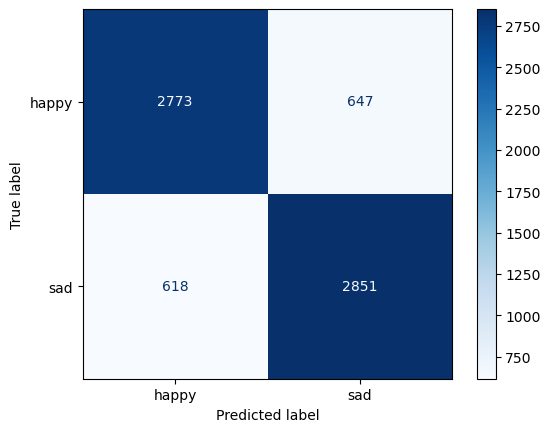

In [250]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["happy", "sad"],
    cmap="Blues"
)

plt.show()

#### KNN

In [275]:
knn = KNeighborsClassifier(n_neighbors=5)

In [276]:
knn.fit(X_train_vec,y_train)

KNeighborsClassifier()

In [277]:
y_pred_knn = knn.predict(X_test_vec)

In [274]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.70      0.85      0.77      3420
           1       0.81      0.64      0.71      3469

    accuracy                           0.74      6889
   macro avg       0.76      0.74      0.74      6889
weighted avg       0.76      0.74      0.74      6889



In [279]:
scores = []

for k in range(1, 31):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_vec, y_train)

    pred = knn.predict(X_dev_vec)

    acc = accuracy_score(y_dev, pred)

    scores.append(acc)

best_k = scores.index(max(scores)) + 1

print("Best k:", best_k)
print("Best Accuracy:", max(scores))

Best k: 19
Best Accuracy: 0.7392920640051721


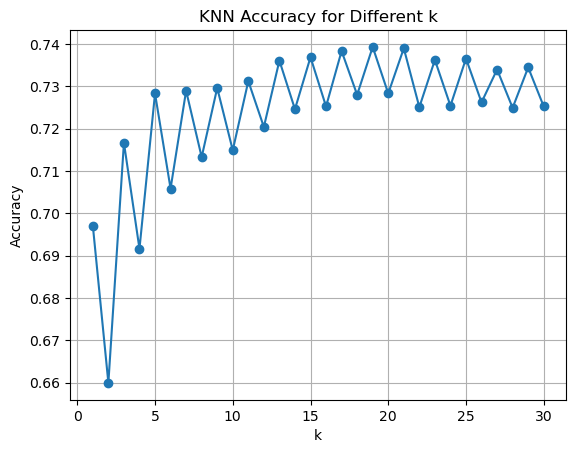

In [280]:
plt.plot(range(1,31), scores, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different k")
plt.grid(True)
plt.show()

### Tf-Idf

#### logestic regression

In [43]:
lr_tf = LogisticRegression(random_state=42)

In [45]:
lr_tf.fit(X_train_tf, y_1_train)

LogisticRegression(random_state=42)

In [46]:
lr_tf_dev_pred = lr_tf.predict(X_dev_tf)

In [47]:
y_pred = lr_tf.predict(X_test_tf)

In [48]:
print(classification_report(y_1_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81      3420
           1       0.80      0.84      0.82      3469

    accuracy                           0.82      6889
   macro avg       0.82      0.82      0.82      6889
weighted avg       0.82      0.82      0.82      6889



In [49]:
cm = confusion_matrix(y_1_test, y_pred)

print(cm)

[[2696  724]
 [ 538 2931]]


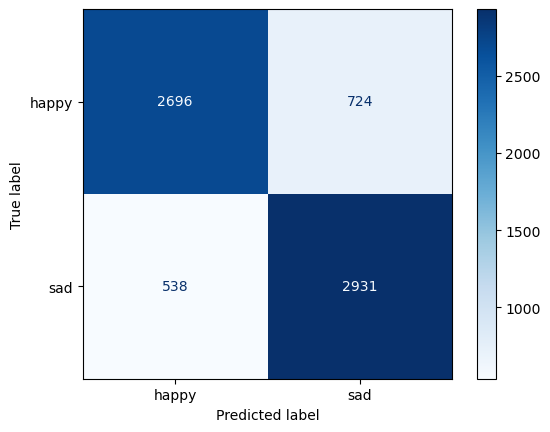

In [50]:
ConfusionMatrixDisplay.from_predictions(
    y_1_test,
    y_pred,
    display_labels=["happy", "sad"],
    cmap="Blues"
)

plt.show()

#### KNN

In [51]:
knn_2 = KNeighborsClassifier(n_neighbors=5)

In [52]:
knn_2.fit(X_train_tf,y_1_train)

KNeighborsClassifier()

In [53]:
y_pred_knn_2 = knn_2.predict(X_test_tf)

In [54]:
print(classification_report(y_1_test,y_pred_knn_2))

              precision    recall  f1-score   support

           0       0.71      0.76      0.74      3420
           1       0.75      0.70      0.72      3469

    accuracy                           0.73      6889
   macro avg       0.73      0.73      0.73      6889
weighted avg       0.73      0.73      0.73      6889



In [57]:
scores = []

for k in range(1, 31):

    knn_2 = KNeighborsClassifier(n_neighbors=k)

    knn_2.fit(X_train_tf, y_1_train)

    pred = knn_2.predict(X_dev_tf)

    acc = accuracy_score(y_1_dev, pred)

    scores.append(acc)

best_k = scores.index(max(scores)) + 1

print("Best k:", best_k)
print("Best Accuracy:", max(scores))

Best k: 29
Best Accuracy: 0.7700016162922256


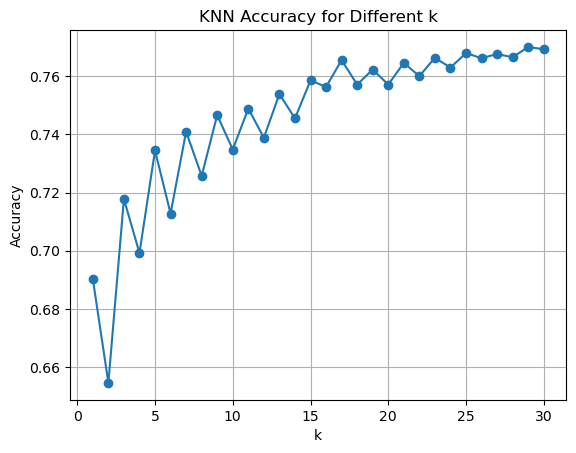

In [58]:
plt.plot(range(1,31), scores, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different k")
plt.grid(True)
plt.show()

## More accuaracy Model

In [ ]:
train_p = pd.DataFrame.sparse.from_spmatrix(X_1_train)
train_p['label'] = y_1_train.values

In [ ]:
clf = setup(
    data=train_p,
    target='label',
    session_id=42,
    verbose=False
)

In [ ]:
best_model = compare_models()